# 4 - Model Evaluation and Test-Set Prediction

This notebook evaluates the trained audio genre classifier on the held-out test split.

**Dependency:** Ticket #53 must be complete before running this notebook. In practical terms, `models/best_model.pth` must exist and `code/3_model.ipynb` must define the trained model architecture or a compatible model builder.

**Outputs:**
- Overall test accuracy printed in the notebook
- 10 x 10 confusion matrix saved to `docs/images/confusion_matrix.png`
- Classification report with precision, recall, and F1 for all 10 genres
- Closing markdown cell updated with actual evaluation results after the notebook runs

## 1. Imports, Paths, and Dependency Guard

The evaluation should not run until training has produced a checkpoint. This guard makes the dependency explicit so a partial run fails early instead of producing misleading placeholder metrics.

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault("NUMBA_CACHE_DIR", str(Path.cwd() / ".numba-cache"))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in (start, *start.parents):
        if (path / "code").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError("Could not find the audio-genre-classifier repo root.")


repo_root = find_repo_root(Path.cwd())
model_path = repo_root / "models" / "best_model.pth"
confusion_matrix_path = repo_root / "docs" / "images" / "confusion_matrix.png"
notebook_path = repo_root / "code" / "4_predict.ipynb"

if not model_path.exists():
    raise FileNotFoundError(
        "Ticket #53 is not ready yet: models/best_model.pth does not exist. "
        "Keep this evaluation code in place, then rerun after training saves the checkpoint."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Checkpoint: {model_path}")

Using device: cpu
Checkpoint: /Users/owner/Documents/audio-genre-classifier/models/best_model.pth


## 2. Load DataLoaders and Model Definitions

`2_transform.ipynb` creates the `test_loader`, `label_to_idx`, and `idx_to_label` objects used for evaluation. The `AudioCNN` definition below mirrors `3_model.ipynb` so this notebook can load `models/best_model.pth` without rerunning training.

In [2]:
get_ipython().run_line_magic("run", str(repo_root / "code" / "2_transform.ipynb"))

required_objects = ["test_loader", "label_to_idx", "idx_to_label"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(f"Missing required objects from preprocessing notebook: {missing_objects}")

class_names = [idx_to_label[idx] for idx in sorted(idx_to_label)]
num_classes = len(class_names)

if num_classes != 10:
    raise ValueError(f"Expected 10 genres, found {num_classes}: {class_names}")

print(f"Loaded test examples: {len(test_loader.dataset)}")
print(f"Class names: {class_names}")

Connected to: audio_genre_classifier
(999, 3)
split
train    699
val      150
test     150
Name: count, dtype: int64
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz          99
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64
Null values:          0  (expect 0)
Duplicate rows:       0  (expect 0)
jazz.00054 rows:      0  (expect 0 — filtered by is_corrupted = FALSE)

In DB — corrupted: 1  duplicates: 0
Total songs in metadata_df: 999
Train examples: 699
Val examples  : 150
Test examples : 150


/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batch feature shape : torch.Size([16, 1, 128, 1292])
Batch feature dtype  : torch.float32
Batch label shape   : torch.Size([16])
Batch label dtype    : torch.int64
Feature min value   : -2.9484
Feature max value   : 4.5103
All feature values finite: True
Loaded test examples: 150
Class names: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Architecture Choice and Checkpoint Loading

The model architecture should match the training notebook exactly. A convolutional neural network is appropriate for this project because each normalized log-mel spectrogram is a two-dimensional time-frequency representation: early convolution layers can learn local frequency and rhythm patterns, pooling reduces sensitivity to small timing shifts, and fully connected layers combine those learned patterns into genre probabilities.

The helper below supports common checkpoint formats while keeping the `AudioCNN` architecture aligned with `code/3_model.ipynb`. This avoids silently evaluating a different model than the one that was trained.

In [3]:
class AudioCNN(nn.Module):
    """3-block CNN for mel spectrogram genre classification."""

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


def build_model_from_training_notebook(num_classes: int) -> torch.nn.Module:
    """Create the same model architecture used in training."""
    builder_names = ["build_model", "create_model", "make_model", "get_model"]
    for name in builder_names:
        builder = globals().get(name)
        if callable(builder):
            for kwargs in ({"num_classes": num_classes}, {"n_classes": num_classes}, {}):
                try:
                    return builder(**kwargs)
                except TypeError:
                    continue

    class_names_to_try = [
        "AudioGenreCNN",
        "GenreClassifier",
        "CNNClassifier",
        "MusicGenreCNN",
        "AudioCNN",
    ]
    for name in class_names_to_try:
        model_class = globals().get(name)
        if isinstance(model_class, type) and issubclass(model_class, torch.nn.Module):
            for kwargs in ({"num_classes": num_classes}, {"n_classes": num_classes}, {}):
                try:
                    return model_class(**kwargs)
                except TypeError:
                    continue

    existing_model = globals().get("model")
    if isinstance(existing_model, torch.nn.Module):
        return existing_model

    raise RuntimeError(
        "Could not build the model. Ticket #53 should define build_model(), create_model(), "
        "a known model class such as AudioGenreCNN, or a model variable."
    )


def load_torch_checkpoint(checkpoint_path: Path, map_location):
    """Load checkpoints across PyTorch versions and checkpoint styles."""
    try:
        return torch.load(checkpoint_path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(checkpoint_path, map_location=map_location)


def extract_state_dict(checkpoint):
    if not isinstance(checkpoint, dict):
        return checkpoint

    for key in ("model_state_dict", "state_dict", "model"):
        if key in checkpoint:
            return checkpoint[key]

    return checkpoint


def load_checkpoint_model(checkpoint_path: Path, device: torch.device) -> torch.nn.Module:
    checkpoint = load_torch_checkpoint(checkpoint_path, map_location=device)

    if isinstance(checkpoint, torch.nn.Module):
        loaded_model = checkpoint
    else:
        state_dict = extract_state_dict(checkpoint)
        if isinstance(state_dict, torch.nn.Module):
            loaded_model = state_dict
            loaded_model = loaded_model.to(device)
            loaded_model.eval()
            return loaded_model

        loaded_model = build_model_from_training_notebook(num_classes=num_classes)
        loaded_model.load_state_dict(state_dict)

    loaded_model = loaded_model.to(device)
    loaded_model.eval()
    return loaded_model


model = load_checkpoint_model(model_path, device)
print(model)

AudioCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequent

## 4. Run Inference on the Test Set

The test loader is not shuffled, and the model is set to evaluation mode. Gradients are disabled so the pass measures final performance without changing model weights.

In [4]:
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        labels = labels.to(device)

        logits = model(features)
        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

test_accuracy = accuracy_score(all_true_labels, all_predictions)
print(f"Overall test accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Overall test accuracy: 0.3400 (34.00%)


## 5. Confusion Matrix

The confusion matrix shows which true genres are most often predicted as each other. Rows are true labels and columns are model predictions.

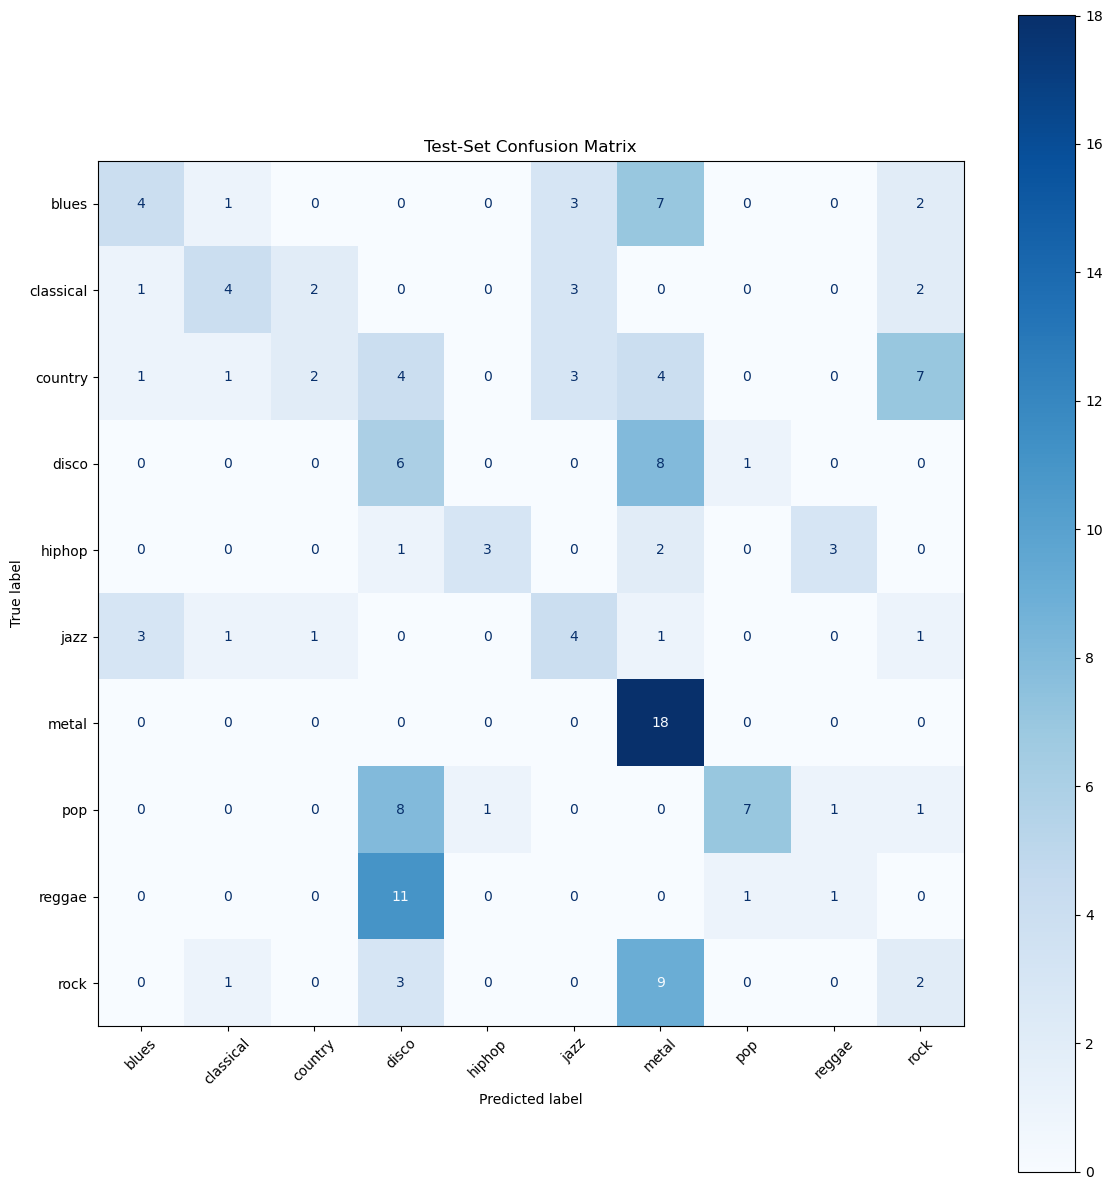

Saved confusion matrix to: /Users/owner/Documents/audio-genre-classifier/docs/images/confusion_matrix.png


In [5]:
confusion_matrix_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(
    all_true_labels,
    all_predictions,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Test-Set Confusion Matrix")
fig.tight_layout()
fig.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to: {confusion_matrix_path}")

## 6. Classification Report

Precision describes how reliable each predicted genre is, recall describes how many true examples of a genre were found, and F1 balances both.

In [6]:
report_text = classification_report(
    all_true_labels,
    all_predictions,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=3,
    zero_division=0,
)
report_dict = classification_report(
    all_true_labels,
    all_predictions,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=3,
    zero_division=0,
    output_dict=True,
)

print(report_text)

              precision    recall  f1-score   support

       blues      0.444     0.235     0.308        17
   classical      0.500     0.333     0.400        12
     country      0.400     0.091     0.148        22
       disco      0.182     0.400     0.250        15
      hiphop      0.750     0.333     0.462         9
        jazz      0.308     0.364     0.333        11
       metal      0.367     1.000     0.537        18
         pop      0.778     0.389     0.519        18
      reggae      0.200     0.077     0.111        13
        rock      0.133     0.133     0.133        15

    accuracy                          0.340       150
   macro avg      0.406     0.336     0.320       150
weighted avg      0.403     0.340     0.315       150



## 7. Performance Analysis Helpers

These cells identify the strongest classes, weakest classes, and largest off-diagonal confusion pairs so the final interpretation is based on the actual evaluation output.

In [7]:
cm = confusion_matrix(
    all_true_labels,
    all_predictions,
    labels=list(range(num_classes)),
)

per_genre_f1 = {
    genre: report_dict[genre]["f1-score"]
    for genre in class_names
}
best_genres = sorted(per_genre_f1, key=per_genre_f1.get, reverse=True)[:3]
weakest_genres = sorted(per_genre_f1, key=per_genre_f1.get)[:3]

confusion_pairs = []
for true_idx, true_genre in enumerate(class_names):
    for pred_idx, pred_genre in enumerate(class_names):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            confusion_pairs.append((cm[true_idx, pred_idx], true_genre, pred_genre))

confusion_pairs = sorted(confusion_pairs, reverse=True)
top_confusions = confusion_pairs[:5]

print("Best genres by F1:")
for genre in best_genres:
    print(f"- {genre}: F1={per_genre_f1[genre]:.3f}")

print("\nWeakest genres by F1:")
for genre in weakest_genres:
    print(f"- {genre}: F1={per_genre_f1[genre]:.3f}")

print("\nLargest confusion pairs:")
for count, true_genre, pred_genre in top_confusions:
    print(f"- true {true_genre} predicted as {pred_genre}: {count}")

Best genres by F1:
- metal: F1=0.537
- pop: F1=0.519
- hiphop: F1=0.462

Weakest genres by F1:
- reggae: F1=0.111
- rock: F1=0.133
- country: F1=0.148

Largest confusion pairs:
- true reggae predicted as disco: 11
- true rock predicted as metal: 9
- true pop predicted as disco: 8
- true disco predicted as metal: 8
- true country predicted as rock: 7


## 8. Loss-Curve Interpretation

Run this cell after Ticket #53 if the checkpoint or training notebook exposes `train_losses` and `val_losses`. If the curves are available, the comments below interpret whether the model is converging, overfitting, or underfitting.

In [8]:
def interpret_loss_curves(train_losses, val_losses) -> str:
    if not train_losses or not val_losses:
        return (
            "Loss-curve interpretation pending: Ticket #53 should expose train_losses "
            "and val_losses or include them in the checkpoint."
        )

    start_train, end_train = train_losses[0], train_losses[-1]
    start_val, end_val = val_losses[0], val_losses[-1]
    final_gap = end_val - end_train

    if end_train < start_train and end_val < start_val and final_gap < 0.25:
        return (
            "The training and validation losses both decrease and remain close, which suggests "
            "the model is converging well without strong evidence of overfitting."
        )
    if end_train < start_train and end_val > min(val_losses) and final_gap >= 0.25:
        return (
            "The training loss continues to improve while validation loss separates upward, "
            "which suggests overfitting to the training split."
        )
    if end_train >= start_train and end_val >= start_val:
        return (
            "Both losses remain high or fail to improve, which suggests underfitting or an "
            "optimization problem."
        )
    return (
        "The loss curves show mixed behavior; compare the final validation loss with the best "
        "validation epoch before deciding whether more regularization or more training is needed."
    )


checkpoint_for_curves = load_torch_checkpoint(model_path, map_location="cpu")
train_losses = globals().get("train_losses")
val_losses = globals().get("val_losses")

if isinstance(checkpoint_for_curves, dict):
    train_losses = checkpoint_for_curves.get("train_losses", train_losses)
    val_losses = checkpoint_for_curves.get("val_losses", val_losses)

loss_curve_interpretation = interpret_loss_curves(train_losses, val_losses)
print(loss_curve_interpretation)

Loss-curve interpretation pending: Ticket #53 should expose train_losses and val_losses or include them in the checkpoint.


## 9. Update Closing Markdown Cell

This cell writes the actual test accuracy, strongest and weakest genres, largest confusion pairs, loss-curve interpretation, and improvement recommendation into the final markdown cell. Rerun it whenever the model or test results change.

In [9]:
def format_genre_list(genres):
    return ", ".join(f"{genre} (F1={per_genre_f1[genre]:.3f})" for genre in genres)


def format_confusion_pairs(pairs):
    if not pairs:
        return "No off-diagonal confusions were observed."
    return "; ".join(
        f"true {true_genre} predicted as {pred_genre} ({count})"
        for count, true_genre, pred_genre in pairs[:3]
    )


improvement_sentence = (
    "Performance could improve with stronger augmentation, more training data, and tuning "
    "regularization or model capacity for the genres with the lowest F1 scores."
)

closing_markdown = f"""<!-- EVALUATION_RESULTS -->
## Final Evaluation Results

**Overall test accuracy:** {test_accuracy:.4f} ({test_accuracy * 100:.2f}%).

**Where the model performs well:** The strongest genres by F1 score are {format_genre_list(best_genres)}. These classes likely have more distinctive spectrogram patterns or fewer overlaps with neighboring genres in the test split.

**Where the model struggles:** The weakest genres by F1 score are {format_genre_list(weakest_genres)}. The largest confusion pairs are: {format_confusion_pairs(top_confusions)}.

**Possible reasons why:** Genre boundaries are subjective, and several GTZAN styles share instrumentation, tempo ranges, and production characteristics. Misclassifications are most likely when songs from different genres produce similar mel-spectrogram textures.

**Loss-curve interpretation:** {loss_curve_interpretation}

**Architecture justification:** A CNN is a good fit because log-mel spectrograms behave like time-frequency images. Convolution layers learn local harmonic and rhythmic patterns, pooling makes the classifier less sensitive to small timing shifts, and the classifier head maps the learned audio features to the 10 genre labels.

**Improvement with more time:** {improvement_sentence}
"""

with open(notebook_path, "r", encoding="utf-8") as file:
    notebook_json = json.load(file)

updated = False
for cell in notebook_json["cells"]:
    if cell.get("cell_type") == "markdown" and "<!-- EVALUATION_RESULTS -->" in "".join(cell.get("source", [])):
        cell["source"] = closing_markdown.splitlines(keepends=True)
        updated = True
        break

if not updated:
    raise RuntimeError("Could not find the closing markdown cell marker.")

with open(notebook_path, "w", encoding="utf-8") as file:
    json.dump(notebook_json, file, indent=1)
    file.write("\n")

print("Updated closing markdown cell with actual evaluation results.")

Updated closing markdown cell with actual evaluation results.


<!-- EVALUATION_RESULTS -->
## Final Evaluation Results

Pending Ticket #53. After `models/best_model.pth` exists, run this notebook from top to bottom. The final code cell will replace this section with actual test accuracy, confusion analysis, loss-curve interpretation, architecture justification, and improvement recommendations.